In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from cbm.data import SCBMSampler
from cbm.data.utils import sample_mrf_prec
from cbm.estimation import estimate_bottleneck_and_mechanism_fcts
from cbm.eval import linear_bottleneck_eval, nonlinear_bottleneck_eval
from cbm import GaussianLangevinMechanism, MacroCausalVar, SCBM

# Turn off wandb logging for this notebook
import wandb
# wandb.init(mode="offline")

In [2]:
def get_rgb_color(x, y):
    hue = (np.arctan2(y, x) + np.pi) / (2*np.pi)
    saturation = np.sqrt(x ** 2 + y ** 2)
    # Standardize
    saturation = saturation / np.max(saturation)
    value = np.ones_like(hue)

    colors = matplotlib.colors.hsv_to_rgb(np.stack((hue, saturation, value)).T)

    return colors

In [3]:
def id_viz(seed, mode='linear'):
    """
    Defines a two node SCBM with given seed and mode (linear or nonlinear), visualized learned and ground-truth bottleneck spaces
    in order to show the learned map between the two. Ideally we want to see an invertible map. 
    """
    assert mode in ['linear', 'nonlinear'], "Mode must be either 'linear' or 'nonlinear'"

    # Random state for reproducibility
    rs = np.random.RandomState(seed=seed)

    sampler = SCBMSampler(seed=seed,
                          d_macro=2,
                          d_micro=4,
                          d_bottleneck=2,
                          bottleneck_mode=mode,
                          mech_mode=mode,
                          p=1.0)
    
    scbm = sampler.sample()

    n_samples = 10000
    samples, bn_samples = scbm.sample(size=n_samples)

    # Estimate bottleneck
    if mode == 'linear':
        estim_mode = 'linear'
    elif mode == 'nonlinear':
        estim_mode = 'mlp'
    estimated_bn_fcts, _ = estimate_bottleneck_and_mechanism_fcts(SCBM=scbm, samples=samples, mode=estim_mode)

    # Apply estimated bottleneck function
    estimated_bn_samples = estimated_bn_fcts[0, 1](samples[0])

    # Sample lots of points, push forward to bottleneck space, only plot some bounded to set (to make plot cleaner)
    n_samples_plot = 100000

    samples_plot, bn_samples_plot = scbm.sample(size=n_samples_plot)

    # Get indices of points in bottleneck space within some bounds
    extreme_val = 5
    bounds = [-extreme_val, extreme_val, -extreme_val, extreme_val]  # x_min, x_max, y_min, y_max
    indices = np.where((bn_samples_plot[0, 1][:, 0] >= bounds[0]) &
                       (bn_samples_plot[0, 1][:, 0] <= bounds[1]) &
                       (bn_samples_plot[0, 1][:, 1] >= bounds[2]) &
                       (bn_samples_plot[0, 1][:, 1] <= bounds[3]))[0]
    
    # Select only points within bounds
    bn_samples_bounded = bn_samples_plot[0, 1][indices]
    # bn_samples_bounded = bn_samples_plot[0, 1]

    print(len(indices))

    # Plot ground truth and learned bottleneck spaces side by side
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    axs[0].scatter(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)
    axs[0].set_title("Ground Truth Bottleneck Space")

    # Select bounded samples in observation space
    samples_bounded = samples_plot[0][indices]
    # Push forward thorugh learned bottleneck function
    bn_samples_learned = estimated_bn_fcts[0, 1](samples_bounded)
    axs[1].scatter(bn_samples_learned[:, 0], bn_samples_learned[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)
    axs[1].set_title("Learned Bottleneck Space")

    # Sanity check: calculate id metric
    estimated_bn_samples_matrix = np.empty_like(estimated_bn_fcts, dtype=object)
    estimated_bn_samples_matrix[0, 1] = estimated_bn_samples
    if mode == 'linear':
        eval_matrix = linear_bottleneck_eval(estimated_bn_samples_matrix, bn_samples)
    else:
        eval_matrix = nonlinear_bottleneck_eval(estimated_bn_samples_matrix, bn_samples, metric='r2')

    id_metric = np.mean(eval_matrix[eval_matrix != None])

    # Add identifiability metric to wandb summary
    wandb.summary.update({f'id_metric': id_metric})

    print(f"Identifiability metric: {id_metric}")

    

## Nonlinear

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: bings. Use `wandb login --relogin` to force relogin


Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1765471762.126714 3502261 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765471762.137069 3502261 service.cc:145] XLA service 0x1046d7f00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765471762.137083 3502261 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765471762.138583 3502261 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765471762.138601 3502261 mps_client.cc:384] XLA backend will use up to 51539214336 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M1 Max

systemMemory: 64.00 GB
maxCacheSize: 24.00 GB

99863
Identifiability metric: 0.7542090778298635


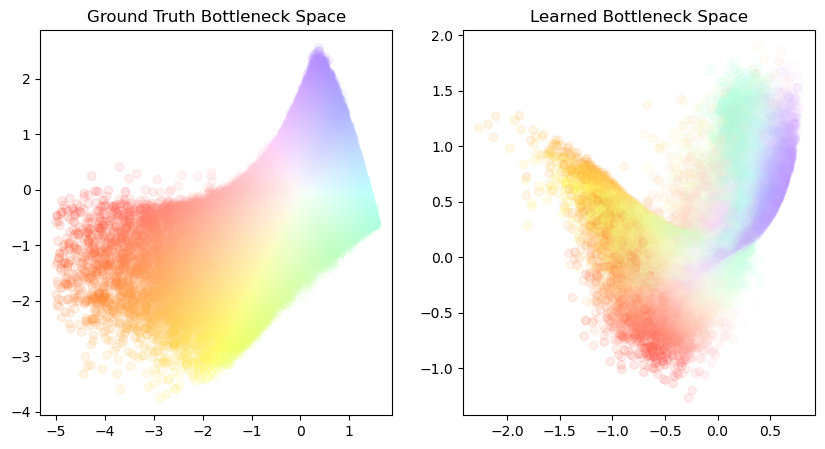

In [4]:
seed = 42

config = dict(
    seed=seed,
)

wandb.init(
        entity='bings',
        project='bottlenecks',
        mode='online',
        config=config
    )

id_viz(seed=seed, mode='nonlinear')

In [ ]:
# 1. Define (simple, two node) model
# 2. Plot bottleneck space with some color pattern
# 3. Map points in bottleneck space back to observation space, mapping color to X points
# 4. Estimate bottleneck
# 5. Apply map form 3., visualize results to show correspondence of points and how space "warps"

# New things to check:
# - Does the invertible map between gt and learned bottleneck always have to be linear for linear bottleneck fcts?
# - Check the identifiability metric, compare different seed cases
# - Why do things look harder to interpret when we dont have an anti diagonal M?
# - Why are the sampled P matrices different for different ways of calling the function?

# 6.11.25: IDentifiability metric helps: weird cases had low scores. Next up: put everything into a wrapper function, output both plots directly. args: seed, lin vs non-nonlin

# 0.69, 0.77, 

# (Semi) working nonlinear seeds: 42, 1924, 7203

## Linear

In [39]:
# Define two node SCBM

# seed = 42  # +
# seed = 90872  # -
# seed = 0  # +
seed = 666  # +
# seed = 720289
rs = np.random.RandomState(seed=seed)

# Shared vars
n_micro = 4  # nr of internal nodes

M = np.ones((n_micro, n_micro))  # internal node sparsity mask
M[0,3] = M[1,2] = M[2,1] = M[3,0] = 0

print(f"M: {M}")

# Node 1
P1 = sample_mrf_prec(dim=n_micro, M=M, rs=rs)  # precision matrix
mech1 = GaussianLangevinMechanism(mu=np.zeros(n_micro), E=np.linalg.inv(P1))

print(f"P1: {P1}")

X1 = MacroCausalVar(parents=None, bottleneck_fcts=None, mechanism=mech1, d=n_micro)

# Node 2
P2 = sample_mrf_prec(dim=n_micro, M=M, rs=rs)  # precision matrix

# Sample linear bottleneck function
d_bottleneck = 2
w_bn = rs.uniform(size=(n_micro, d_bottleneck))
# Make sure rank is correct
while np.linalg.matrix_rank(w_bn) < d_bottleneck:
    w_bn = rs.uniform(size=(n_micro, d_bottleneck))

def f_bn(x):
    return x @ w_bn

# Sample linear mechanism function
w_mech = rs.uniform(size=(d_bottleneck, n_micro))
while np.linalg.matrix_rank(w_mech) < d_bottleneck:
    w_mech = rs.uniform(size=(d_bottleneck, n_micro))

def f_mech(x):
    return x @ w_mech

mech2 = GaussianLangevinMechanism(mu=f_mech, E=np.linalg.inv(P2))

X2 = MacroCausalVar(parents=[X1], bottleneck_fcts=[f_bn], mechanism=mech2, d=n_micro)

variables = np.empty(2, dtype=object)
variables[0] = X1
variables[1] = X2

A = np.asarray([[0, 1],
                [0, 0]])
d_bottleneck_matrix = np.empty_like(A, dtype=object)
d_bottleneck_matrix[0, 1] = 2

scbm = SCBM(variables=variables, A=A, d_bottleneck_matrix=d_bottleneck_matrix, seed=seed)

M: [[1. 1. 1. 0.]
 [1. 1. 0. 1.]
 [1. 0. 1. 1.]
 [0. 1. 1. 1.]]
P1: [[0.95828381 0.59129966 0.49240641 0.        ]
 [0.59129966 1.62792333 0.         0.01208656]
 [0.49240641 0.         0.71083214 0.02018837]
 [0.         0.01208656 0.02018837 0.01254406]]


In [40]:
n_samples = 10000
samples, bn_samples = scbm.sample(size=n_samples)

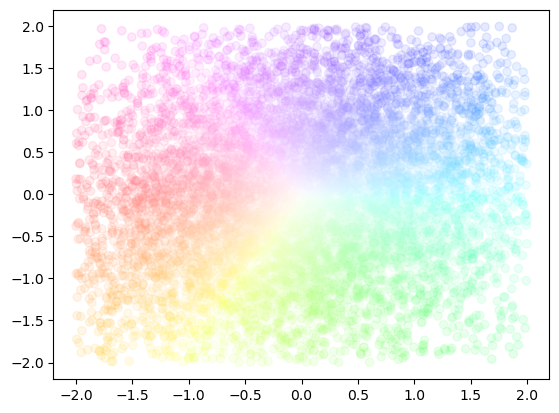

In [41]:
# Sample lots of points, push forward to bottleneck space, only plot some bounded to set (to make plot cleaner)
n_samples = 10000

samples_new, bn_samples_new = scbm.sample(size=n_samples)

# Get indices of points in bottleneck space within some bounds
bounds = [-2, 2, -2, 2]  # x_min, x_max, y_min, y_max
indices = np.where((bn_samples_new[0, 1][:, 0] >= bounds[0]) &
                   (bn_samples_new[0, 1][:, 0] <= bounds[1]) &
                   (bn_samples_new[0, 1][:, 1] >= bounds[2]) &
                   (bn_samples_new[0, 1][:, 1] <= bounds[3]))[0]

# Select only points within bounds
bn_samples_bounded = bn_samples_new[0, 1][indices]

fig, ax = plt.subplots()

ax.scatter(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)

In [42]:
# Estimate bottleneck
estimated_bn_fcts, _ = estimate_bottleneck_and_mechanism_fcts(SCBM=scbm, samples=samples, mode='linear')

In [43]:
# Apply estimated bottleneck function
estimated_bn_samples = estimated_bn_fcts[0, 1](samples[0])

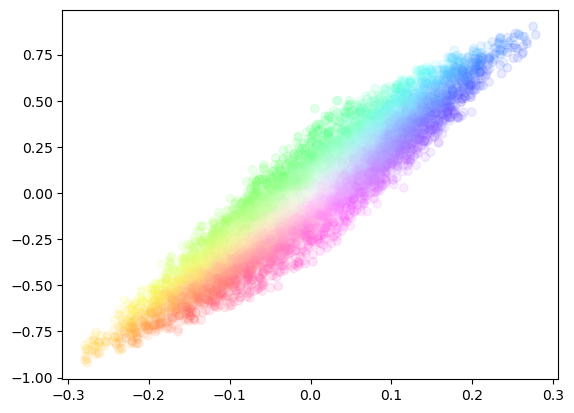

In [44]:
# Select bounded samples in observation space
samples_bounded = samples_new[0][indices]

# Push forward thorugh learned bottleneck function
bn_samples_learned = estimated_bn_fcts[0, 1](samples_bounded)

fig, ax = plt.subplots()

ax.scatter(bn_samples_learned[:, 0], bn_samples_learned[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)

In [37]:
# Sanity check: calculate id metric
estimated_bn_samples_matrix = np.empty_like(estimated_bn_fcts, dtype=object)
estimated_bn_samples_matrix[0, 1] = estimated_bn_samples
eval_matrix = linear_bottleneck_eval(estimated_bn_samples_matrix, bn_samples)

print(np.mean(eval_matrix[eval_matrix != None]))

0.9970009032603998


Text(0.5, 1.0, 'Learned Bottleneck Space')

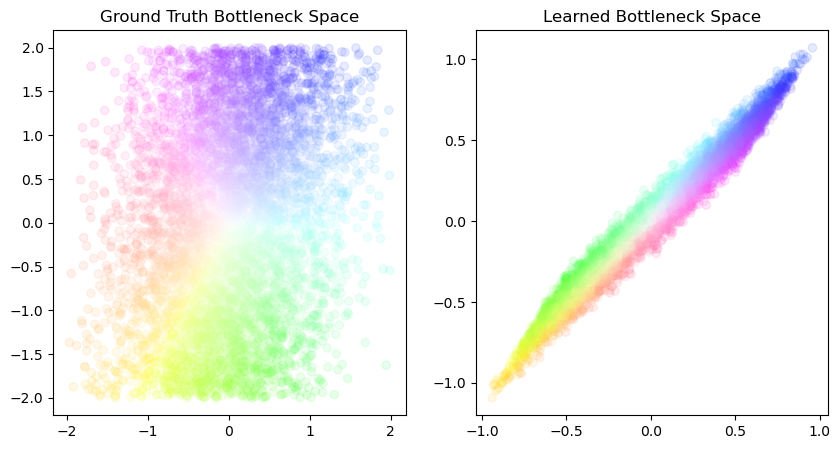

In [3]:
# Let's repeat the above but using the functions we define for other experiements



# Sample a linear SCBM with two (macro) nodes
seed = 3948
rs = np.random.RandomState(seed=seed)

sampler = SCBMSampler(seed=seed,
                      d_macro=2,
                      d_micro=4,
                      d_bottleneck=2,
                      bottleneck_mode='linear',
                      mech_mode='linear',
                      p=1.0)

scbm_lin = sampler.sample()

n_samples = 10000
samples, bn_samples = scbm_lin.sample(size=n_samples)

# Estimate bottleneck
estimated_bn_fcts, _ = estimate_bottleneck_and_mechanism_fcts(SCBM=scbm_lin, samples=samples, mode='linear')

# Apply estimated bottleneck function
estimated_bn_samples = estimated_bn_fcts[0, 1](samples[0])

# Sample lots of points, push forward to bottleneck space, only plot some bounded to set (to make plot cleaner)
n_samples_plot = 10000

samples_plot, bn_samples_plot = scbm_lin.sample(size=n_samples_plot)

# Get indices of points in bottleneck space within some bounds
bounds = [-2, 2, -2, 2]  # x_min, x_max, y_min, y_max
indices = np.where((bn_samples_plot[0, 1][:, 0] >= bounds[0]) &
                   (bn_samples_plot[0, 1][:, 0] <= bounds[1]) &
                   (bn_samples_plot[0, 1][:, 1] >= bounds[2]) &
                   (bn_samples_plot[0, 1][:, 1] <= bounds[3]))[0]

# Select only points within bounds
bn_samples_bounded = bn_samples_plot[0, 1][indices]

# Plot ground truth and learned bottleneck spaces side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].scatter(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)
axs[0].set_title("Ground Truth Bottleneck Space")

# Select bounded samples in observation space
samples_bounded = samples_plot[0][indices]
# Push forward thorugh learned bottleneck function
bn_samples_learned = estimated_bn_fcts[0, 1](samples_bounded)
axs[1].scatter(bn_samples_learned[:, 0], bn_samples_learned[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)
axs[1].set_title("Learned Bottleneck Space")

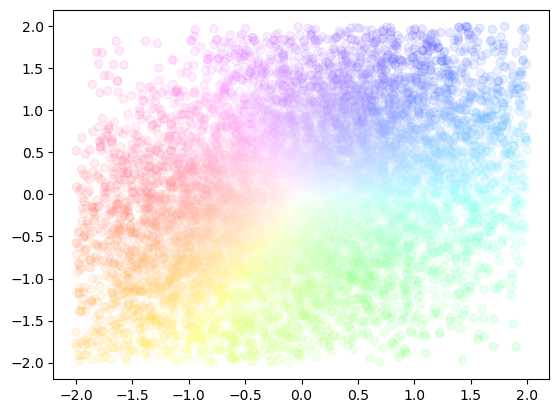

In [46]:
fig, ax = plt.subplots()

ax.scatter(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)

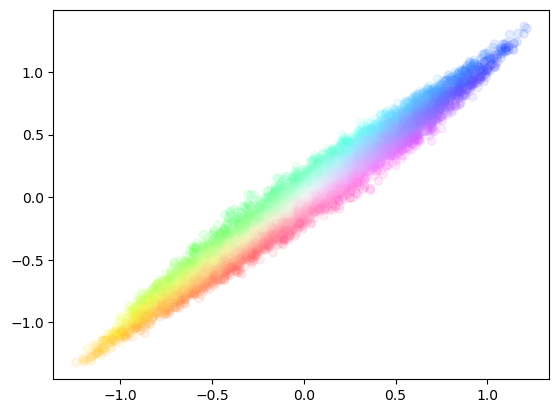

In [47]:
# Select bounded samples in observation space
samples_bounded = samples_plot[0][indices]

# Push forward thorugh learned bottleneck function
bn_samples_learned = estimated_bn_fcts[0, 1](samples_bounded)

fig, ax = plt.subplots()

ax.scatter(bn_samples_learned[:, 0], bn_samples_learned[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)

In [48]:
# Sanity check: calculate id metric
estimated_bn_samples_matrix = np.empty_like(estimated_bn_fcts, dtype=object)
estimated_bn_samples_matrix[0, 1] = estimated_bn_samples
eval_matrix = linear_bottleneck_eval(estimated_bn_samples_matrix, bn_samples)

print(np.mean(eval_matrix[eval_matrix != None]))

0.9897463903633832


100000
Identifiability metric: 0.9495768190089816


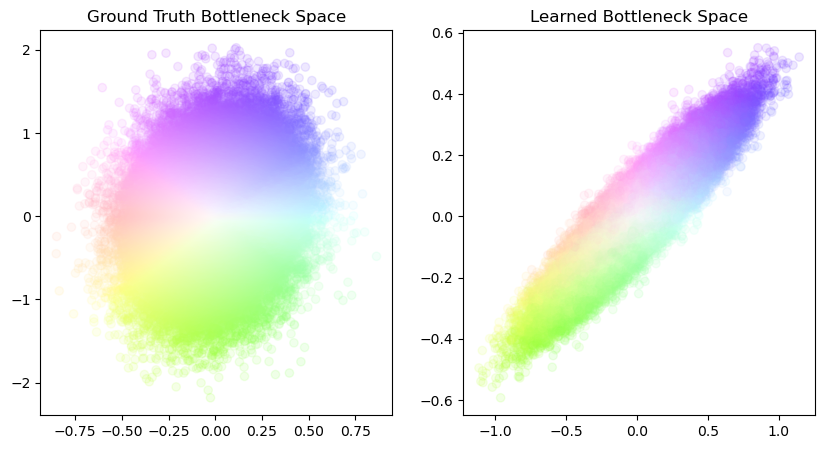

In [4]:
id_viz(seed=8878, mode='linear')

In [ ]:
# List of interesting seeds:
# +: 666, 86888, 4231, 123, 12, 8878
# -: 432432

In [ ]:
# List of interesting seeds:
# +: 42, 923, 83, these are for single sampled matrix and sigmoid or leaky relu
# -: 8523

In [ ]:
# Notes on nonlinear viz:
# - all ground truth spaces look similar: values fall on the diagonal, dont extend beyond [-0.3, -0.3]
# -> leakurelu does not result in "space filling" curve?

In [11]:
w = np.random.uniform(size=(4, 2))

In [17]:
Q, R = np.linalg.qr(w)

In [18]:
Q

array([[-0.03333786,  0.18755409],
       [-0.85800012, -0.50897676],
       [-0.43351366,  0.69816735],
       [-0.27347814,  0.46725633]])